# Compare MATLAB and Python model outputs

This notebook compares legacy MATLAB `.mat` outputs against Python `.mat` outputs.
It first tries exact field-name matches, then falls back to the old-name to new-name mapping in `src/variable_name_lookup_v2.md`.
It reports both maximum absolute error and maximum relative error. Relative error is stabilized with a small floor so near-zero fields do not blow up spuriously.


In [1]:
from pathlib import Path
import re

import numpy as np
from scipy.io import loadmat


def find_repo_dir(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").exists() and (candidate / "outputs").exists():
            return candidate
    raise RuntimeError("Could not locate repo root")


REPO_DIR = find_repo_dir()
PYTHON_OUTPUT_DIR = REPO_DIR / "output"
MATLAB_OUTPUT_DIR = REPO_DIR / "outputs"
LOOKUP_TABLE_PATH = REPO_DIR / "src" / "variable_name_lookup_v2.md"

print(f"REPO_DIR={REPO_DIR}")
print(f"PYTHON_OUTPUT_DIR={PYTHON_OUTPUT_DIR}")
print(f"MATLAB_OUTPUT_DIR={MATLAB_OUTPUT_DIR}")
print(f"LOOKUP_TABLE_PATH={LOOKUP_TABLE_PATH}")


REPO_DIR=/Users/huaizefeng/Documents/GitHub/johnson-field-berry-2021-oeco
PYTHON_OUTPUT_DIR=/Users/huaizefeng/Documents/GitHub/johnson-field-berry-2021-oeco/output
MATLAB_OUTPUT_DIR=/Users/huaizefeng/Documents/GitHub/johnson-field-berry-2021-oeco/outputs
LOOKUP_TABLE_PATH=/Users/huaizefeng/Documents/GitHub/johnson-field-berry-2021-oeco/src/variable_name_lookup_v2.md


In [2]:
FOCUS_FIELDS = ("An_a", "JP700_a", "PAM4_a", "An_sa", "C_sa")
PREFERRED_SUFFIXES = ("-report", "-metadata-check", "-renamecheck", "-renamecheck2", "-relayout", "-py")


def load_lookup_field_map(lookup_path):
    pattern = re.compile(r"^\|\s*`([^`]+)`\s*\|\s*`([^`]+)`\s*\|")
    field_map = {}
    for line in lookup_path.read_text(encoding="utf-8").splitlines():
        match = pattern.match(line)
        if match:
            legacy_name, standard_name = match.groups()
            field_map[legacy_name] = standard_name
    return field_map


FIELD_MAP = load_lookup_field_map(LOOKUP_TABLE_PATH)


def load_mat_struct(mat_path, key):
    payload = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    return payload[key]


def struct_field_names(struct):
    if hasattr(struct, "_fieldnames"):
        return list(struct._fieldnames)
    return list(vars(struct).keys())


def resolve_candidate_field(reference_name, candidate_fields):
    if reference_name in candidate_fields:
        return reference_name

    standard_name = FIELD_MAP.get(reference_name, reference_name)
    if standard_name in candidate_fields:
        return standard_name

    return None


def _coerce_numeric_pair(reference_value, candidate_value):
    reference = np.asarray(reference_value, dtype=float)
    candidate = np.asarray(candidate_value, dtype=float)

    if reference.shape != candidate.shape:
        raise ValueError(f"shape mismatch: {reference.shape} != {candidate.shape}")

    if reference.size == 0:
        return reference, candidate

    both_nan = np.isnan(reference) & np.isnan(candidate)
    reference = np.where(both_nan, 0.0, reference)
    candidate = np.where(both_nan, 0.0, candidate)
    return reference, candidate


def max_abs_diff(reference_value, candidate_value):
    reference, candidate = _coerce_numeric_pair(reference_value, candidate_value)

    if reference.size == 0:
        return 0.0

    diff = np.abs(reference - candidate)
    if np.all(np.isnan(diff)):
        return 0.0

    return float(np.nanmax(diff))


def max_rel_diff(reference_value, candidate_value, floor_ratio=1e-12, floor_abs=1e-15):
    reference, candidate = _coerce_numeric_pair(reference_value, candidate_value)

    if reference.size == 0:
        return 0.0

    finite_reference = np.abs(reference[np.isfinite(reference)])
    reference_scale = float(np.nanmax(finite_reference)) if finite_reference.size else 0.0
    zero_floor = max(reference_scale * floor_ratio, floor_abs)

    diff = np.abs(reference - candidate)
    denom = np.maximum(np.abs(reference), zero_floor)
    rel = diff / denom
    both_effectively_zero = (np.abs(reference) <= zero_floor) & (np.abs(candidate) <= zero_floor)
    rel = np.where(both_effectively_zero, 0.0, rel)

    if np.all(np.isnan(rel)):
        return 0.0

    return float(np.nanmax(rel))


def compare_structs(reference_struct, candidate_struct):
    numeric_diffs = []
    skipped_fields = []
    shape_mismatches = []
    missing_fields = []
    matched_fields = []

    candidate_fields = set(struct_field_names(candidate_struct))

    for reference_name in sorted(struct_field_names(reference_struct)):
        candidate_name = resolve_candidate_field(reference_name, candidate_fields)
        if candidate_name is None:
            missing_fields.append((reference_name, FIELD_MAP.get(reference_name, reference_name)))
            continue

        matched_fields.append((reference_name, candidate_name))

        try:
            reference_value = getattr(reference_struct, reference_name)
            candidate_value = getattr(candidate_struct, candidate_name)
            abs_diff = max_abs_diff(reference_value, candidate_value)
            rel_diff = max_rel_diff(reference_value, candidate_value)
        except ValueError as exc:
            if "shape mismatch" in str(exc):
                reference_array = np.asarray(getattr(reference_struct, reference_name), dtype=float)
                candidate_array = np.asarray(getattr(candidate_struct, candidate_name), dtype=float)
                shape_mismatches.append((reference_name, candidate_name, reference_array.shape, candidate_array.shape))
                continue
            skipped_fields.append((reference_name, candidate_name))
            continue
        except (AttributeError, TypeError):
            skipped_fields.append((reference_name, candidate_name))
            continue

        numeric_diffs.append((reference_name, candidate_name, abs_diff, rel_diff))

    numeric_diffs.sort(key=lambda item: item[2], reverse=True)
    return numeric_diffs, skipped_fields, shape_mismatches, missing_fields, matched_fields


def choose_existing_candidate(base_output_name, preferred_suffixes=PREFERRED_SUFFIXES):
    for suffix in preferred_suffixes:
        candidate_path = PYTHON_OUTPUT_DIR / f"{base_output_name}{suffix}" / f"{base_output_name}-modeloutputs.mat"
        if candidate_path.exists():
            return suffix, candidate_path
    raise FileNotFoundError(f"No candidate output found for {base_output_name!r} under {PYTHON_OUTPUT_DIR}")


def compare_case(base_output_name, candidate_suffix=None, key="m", top_n=10, missing_n=10):
    reference_path = MATLAB_OUTPUT_DIR / base_output_name / f"{base_output_name}-modeloutputs.mat"
    if not reference_path.exists():
        raise FileNotFoundError(reference_path)

    if candidate_suffix is None:
        candidate_suffix, candidate_path = choose_existing_candidate(base_output_name)
    else:
        candidate_path = PYTHON_OUTPUT_DIR / f"{base_output_name}{candidate_suffix}" / f"{base_output_name}-modeloutputs.mat"
        if not candidate_path.exists():
            raise FileNotFoundError(candidate_path)

    reference_struct = load_mat_struct(reference_path, key)
    candidate_struct = load_mat_struct(candidate_path, key)
    numeric_diffs, skipped_fields, shape_mismatches, missing_fields, matched_fields = compare_structs(reference_struct, candidate_struct)

    exact_matches = sum(reference_name == candidate_name for reference_name, candidate_name in matched_fields)
    mapped_matches = len(matched_fields) - exact_matches
    top_relative_diffs = sorted(numeric_diffs, key=lambda item: item[3], reverse=True)

    print(f"[case] {base_output_name}{candidate_suffix}")
    print(f"[matched] total={len(matched_fields)} exact={exact_matches} mapped={mapped_matches}")
    print(f"[missing candidate fields] {len(missing_fields)}")

    print("[focus]")
    candidate_fields = set(struct_field_names(candidate_struct))
    for reference_name in FOCUS_FIELDS:
        candidate_name = resolve_candidate_field(reference_name, candidate_fields)
        label = reference_name
        if candidate_name is not None and reference_name != candidate_name:
            label = f"{reference_name} -> {candidate_name}"

        if candidate_name is None:
            fallback_name = FIELD_MAP.get(reference_name, reference_name)
            print(f"  {reference_name} -> {fallback_name}: missing")
            continue

        abs_diff = max_abs_diff(getattr(reference_struct, reference_name), getattr(candidate_struct, candidate_name))
        rel_diff = max_rel_diff(getattr(reference_struct, reference_name), getattr(candidate_struct, candidate_name))
        print(f"  {label}: abs={abs_diff:.6g} rel={rel_diff:.6g}")

    print("[top absolute diffs]")
    for reference_name, candidate_name, abs_diff, rel_diff in numeric_diffs[:top_n]:
        label = reference_name if reference_name == candidate_name else f"{reference_name} -> {candidate_name}"
        print(f"  {label}: abs={abs_diff:.6g} rel={rel_diff:.6g}")

    print("[top relative diffs]")
    for reference_name, candidate_name, abs_diff, rel_diff in top_relative_diffs[:top_n]:
        label = reference_name if reference_name == candidate_name else f"{reference_name} -> {candidate_name}"
        print(f"  {label}: rel={rel_diff:.6g} abs={abs_diff:.6g}")

    if missing_fields:
        print("[missing field examples]")
        for reference_name, candidate_name in missing_fields[:missing_n]:
            print(f"  {reference_name} -> {candidate_name}")

    if skipped_fields:
        print(f"[skipped non-numeric] {len(skipped_fields)} fields")

    if shape_mismatches:
        print(f"[shape mismatches] {len(shape_mismatches)} fields")
        for reference_name, candidate_name, reference_shape, candidate_shape in shape_mismatches[:top_n]:
            print(f"  {reference_name} -> {candidate_name}: {reference_shape} != {candidate_shape}")

    print()
    return {
        "base_output_name": base_output_name,
        "candidate_suffix": candidate_suffix,
        "numeric_diffs": numeric_diffs,
        "skipped_fields": skipped_fields,
        "shape_mismatches": shape_mismatches,
        "missing_fields": missing_fields,
        "matched_fields": matched_fields,
    }


print(f"lookup table entries={len(FIELD_MAP)}")


lookup table entries=198


In [3]:
DEFAULT_CASES = (
    "Example1-Light-C3",
    "Example1-Light-Type-I-C3-C4",
    "Example1-Light-NADP-ME-C4",
    "Example2-CO2-C3",
    "Example2-CO2-Type-I-C3-C4",
    "Example2-CO2-NADP-ME-C4",
    "Example3-Temperature-C3",
    "Example3-Temperature-Type-I-C3-C4",
    "Example3-Temperature-NADP-ME-C4",
)

results = []
for base_output_name in DEFAULT_CASES:
    try:
        results.append(compare_case(base_output_name))
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")


[case] Example1-Light-C3-report
[matched] total=145 exact=4 mapped=141
[missing candidate fields] 0
[focus]
  An_a -> A_net_actual: abs=3.38813e-21 rel=2.74636e-16
  JP700_a -> J_PSI_actual: abs=1.35525e-20 rel=1.6121e-16
  PAM4_a -> Phi_PSII: abs=3.33067e-16 rel=2.53724e-15
  An_sa -> A_net_s_actual: abs=0 rel=0
  C_sa -> CO2_s_actual: abs=0 rel=0
[top absolute diffs]
  Kn2_ma -> k_N2_m_actual: abs=5.72205e-06 rel=1.33854e-15
  PAM3_a -> NPQ: abs=8.88178e-15 rel=1.49593e-15
  PAM1_a -> qP: abs=6.10623e-16 rel=2.25772e-15
  PAM2_a -> qL: abs=4.44089e-16 rel=2.77172e-15
  PAM4_a -> Phi_PSII: abs=3.33067e-16 rel=2.53724e-15
  PAM5_a -> Phi_NPQ: abs=3.33067e-16 rel=8.31982e-16
  phi2n_ma -> phi_n2_m_actual: abs=3.33067e-16 rel=1.04512e-15
  phi1N_ma -> phi_N1_m_actual: abs=2.22045e-16 rel=8.16355e-16
  phi2N_ma -> phi_N2_m_actual: abs=2.22045e-16 rel=9.70646e-16
  phi2P_ma -> phi_P2_m_actual: abs=2.22045e-16 rel=6.20038e-16
[top relative diffs]
  PAM2_a -> qL: rel=2.77172e-15 abs=4.44089e

## Summary Table And Plots

The next cell summarizes field matching and numeric differences across all default cases, and saves a compact figure under `output/compare_model_outputs/compare_summary.png`.
Relative error uses `abs(candidate - reference) / max(abs(reference), max(abs(reference)) * 1e-12, 1e-15)`, with values treated as `0` when both sides are below the floor.


,case,candidate_suffix,matched_fields,exact_matches,mapped_matches,missing_fields,top_abs_field_reference,top_abs_field_candidate,top_abs_diff,top_rel_field_reference,top_rel_field_candidate,top_rel_diff
0,Example3-Temperature-NADP-ME-C4,-report,167,4,163,0,Kn2_sa,k_N2_s_actual,0.001733,Kn2_sa,k_N2_s_actual,7.844843e-13
1,Example2-CO2-NADP-ME-C4,-report,167,4,163,0,Kn2_sa,k_N2_s_actual,0.001194,JP680_scj,J_PSII_s_cj,5.101853e-13
2,Example1-Light-NADP-ME-C4,-report,167,4,163,0,Kn2_sa,k_N2_s_actual,0.001154,Kn2_sa,k_N2_s_actual,8.199940e-13
3,Example1-Light-Type-I-C3-C4,-report,175,4,171,0,Kn2_sa,k_N2_s_actual,0.000808,Kn2_sa,k_N2_s_actual,5.958831e-12
4,Example3-Temperature-Type-I-C3-C4,-report,175,4,171,0,Kn2_sa,k_N2_s_actual,0.000034,L_C_sa,Leak_CO2_s_actual,1.180931e-13
5,Example2-CO2-Type-I-C3-C4,-report,175,4,171,0,Kn2_sa,k_N2_s_actual,0.000014,L_C_sa,Leak_CO2_s_actual,8.893094e-14
6,Example3-Temperature-C3,-report,145,4,141,0,Kn2_ma,k_N2_m_actual,0.000009,Rd,R_d,6.747309e-15
7,Example1-Light-C3,-report,145,4,141,0,Kn2_ma,k_N2_m_actual,0.000006,PAM2_a,qL,2.771723e-15
8,Example2-CO2-C3,-report,145,4,141,0,Kn2_ma,k_N2_m_actual,0.000006,PAM2_a,qL,2.425784e-15


,reference_field,candidate_field,abs_diff,rel_diff
0,Kn2_sa,k_N2_s_actual,1.732826e-03,5.958831e-12
1,Kn2_ma,k_N2_m_actual,1.239777e-05,2.263978e-15
2,S,Specificity,6.821210e-12,2.351178e-15
3,PAM3_a,NPQ,4.639844e-12,3.185216e-13
4,phi2N_sa,phi_N2_s_actual,1.798561e-13,5.802517e-12
5,phi2n_sa,phi_n2_s_actual,1.785239e-13,5.845910e-12
6,phi2P_sa,phi_P2_s_actual,1.331157e-13,3.661700e-13
7,phi2u_sa,phi_u2_s_actual,1.160738e-13,3.278211e-13
8,phi2D_sa,phi_D2_s_actual,7.652212e-14,5.076189e-13
9,phi2p_sa,phi_p2_s_actual,6.927792e-14,1.863505e-13


,reference_field,candidate_field,abs_diff,rel_diff
0,Kn2_sa,k_N2_s_actual,1.732826e-03,5.958831e-12
1,phi2n_sa,phi_n2_s_actual,1.785239e-13,5.845910e-12
2,phi2N_sa,phi_N2_s_actual,1.798561e-13,5.802517e-12
3,Fmp_sa,F_m_prime_s_actual,2.288100e-15,1.098711e-12
4,JP680_scj,J_PSII_s_cj,2.412350e-17,5.387614e-13
5,JP680_sc,J_PSII_s_c,4.445229e-18,5.387614e-13
6,phi2D_sa,phi_D2_s_actual,7.652212e-14,5.076189e-13
7,phi2F_sa,phi_F2_s_actual,6.956241e-15,5.075959e-13
8,Fs_sa,F_s_s_actual,1.111524e-15,5.075579e-13
9,C_scj,CO2_s_cj,5.048045e-16,4.584843e-13


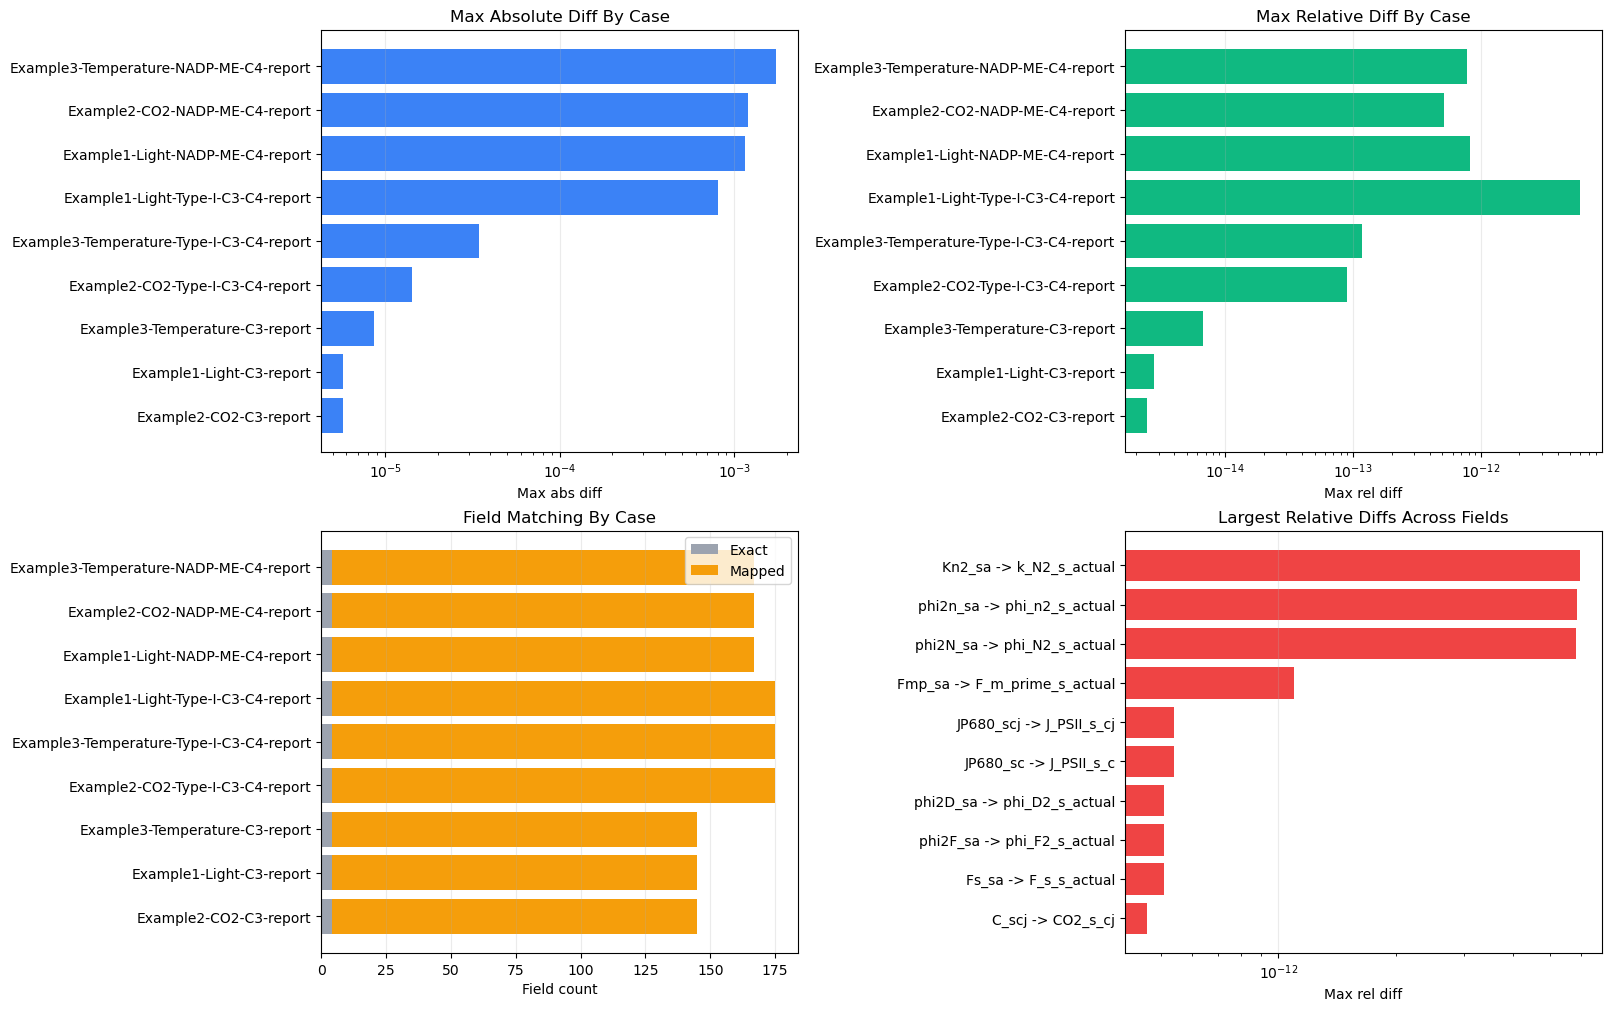

[saved] /Users/huaizefeng/Documents/GitHub/johnson-field-berry-2021-oeco/output/compare_model_outputs/compare_summary.png


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

summary_rows = []
field_rows = []

for result in results:
    numeric_diffs = result["numeric_diffs"]
    matched_fields = result["matched_fields"]
    exact_count = sum(reference_name == candidate_name for reference_name, candidate_name in matched_fields)
    mapped_count = len(matched_fields) - exact_count
    top_abs_reference_name, top_abs_candidate_name, top_abs_diff, top_abs_rel = max(numeric_diffs, key=lambda item: item[2])
    top_rel_reference_name, top_rel_candidate_name, top_rel_abs, top_rel_diff = max(numeric_diffs, key=lambda item: item[3])
    summary_rows.append({
        "case": result["base_output_name"],
        "candidate_suffix": result["candidate_suffix"],
        "matched_fields": len(matched_fields),
        "exact_matches": exact_count,
        "mapped_matches": mapped_count,
        "missing_fields": len(result["missing_fields"]),
        "top_abs_field_reference": top_abs_reference_name,
        "top_abs_field_candidate": top_abs_candidate_name,
        "top_abs_diff": top_abs_diff,
        "top_rel_field_reference": top_rel_reference_name,
        "top_rel_field_candidate": top_rel_candidate_name,
        "top_rel_diff": top_rel_diff,
    })
    for reference_name, candidate_name, abs_diff, rel_diff in numeric_diffs:
        field_rows.append({
            "case": result["base_output_name"],
            "reference_field": reference_name,
            "candidate_field": candidate_name,
            "abs_diff": abs_diff,
            "rel_diff": rel_diff,
        })

summary_df = pd.DataFrame(summary_rows).sort_values(["top_abs_diff", "case"], ascending=[False, True]).reset_index(drop=True)
field_df = pd.DataFrame(field_rows)
field_summary_df = (
    field_df.groupby(["reference_field", "candidate_field"], as_index=False)[["abs_diff", "rel_diff"]]
    .max()
    .reset_index(drop=True)
)
field_abs_summary_df = field_summary_df.sort_values("abs_diff", ascending=False).reset_index(drop=True)
field_rel_summary_df = field_summary_df.sort_values("rel_diff", ascending=False).reset_index(drop=True)

display(summary_df[[
    "case",
    "candidate_suffix",
    "matched_fields",
    "exact_matches",
    "mapped_matches",
    "missing_fields",
    "top_abs_field_reference",
    "top_abs_field_candidate",
    "top_abs_diff",
    "top_rel_field_reference",
    "top_rel_field_candidate",
    "top_rel_diff",
]])
display(field_abs_summary_df.head(12))
display(field_rel_summary_df.head(12))

plot_df = summary_df.copy()
plot_df["case_label"] = plot_df["case"] + plot_df["candidate_suffix"]
plot_df = plot_df.iloc[::-1]

top_rel_fields_plot_df = field_rel_summary_df.head(10).iloc[::-1].copy()
top_rel_fields_plot_df["field_label"] = top_rel_fields_plot_df.apply(
    lambda row: row["reference_field"] if row["reference_field"] == row["candidate_field"] else row["reference_field"] + " -> " + row["candidate_field"],
    axis=1,
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

axes[0, 0].barh(plot_df["case_label"], plot_df["top_abs_diff"], color="#3b82f6")
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("Max Absolute Diff By Case")
axes[0, 0].set_xlabel("Max abs diff")

axes[0, 1].barh(plot_df["case_label"], plot_df["top_rel_diff"], color="#10b981")
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Max Relative Diff By Case")
axes[0, 1].set_xlabel("Max rel diff")

axes[1, 0].barh(plot_df["case_label"], plot_df["exact_matches"], color="#9ca3af", label="Exact")
axes[1, 0].barh(plot_df["case_label"], plot_df["mapped_matches"], left=plot_df["exact_matches"], color="#f59e0b", label="Mapped")
axes[1, 0].set_title("Field Matching By Case")
axes[1, 0].set_xlabel("Field count")
axes[1, 0].legend()

axes[1, 1].barh(top_rel_fields_plot_df["field_label"], top_rel_fields_plot_df["rel_diff"], color="#ef4444")
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("Largest Relative Diffs Across Fields")
axes[1, 1].set_xlabel("Max rel diff")

for ax in axes.flat:
    ax.grid(axis="x", alpha=0.25)

output_dir = REPO_DIR / "output" / "compare_model_outputs"
output_dir.mkdir(parents=True, exist_ok=True)
summary_plot_path = output_dir / "compare_summary.png"
fig.savefig(summary_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"[saved] {summary_plot_path}")


In [5]:
# Custom one-off comparison
BASE_OUTPUT_NAME = "Example1-Light-Type-I-C3-C4"
CANDIDATE_SUFFIX = "-report"  # set to None to auto-detect

compare_case(BASE_OUTPUT_NAME, candidate_suffix=CANDIDATE_SUFFIX)


[case] Example1-Light-Type-I-C3-C4-report
[matched] total=175 exact=4 mapped=171
[missing candidate fields] 0
[focus]
  An_a -> A_net_actual: abs=3.38813e-21 rel=1.08224e-15
  JP700_a -> J_PSI_actual: abs=1.35525e-20 rel=1.68009e-16
  PAM4_a -> Phi_PSII: abs=6.66134e-15 rel=7.76396e-15
  An_sa -> A_net_s_actual: abs=2.96462e-21 rel=2.14e-14
  C_sa -> CO2_s_actual: abs=1.0842e-18 rel=1.63179e-15
[top absolute diffs]
  Kn2_sa -> k_N2_s_actual: abs=0.000808239 rel=5.95883e-12
  Kn2_ma -> k_N2_m_actual: abs=1.23978e-05 rel=2.26398e-15
  phi2N_sa -> phi_N2_s_actual: abs=1.51087e-13 rel=5.80252e-12
  phi2P_sa -> phi_P2_s_actual: abs=1.33116e-13 rel=1.55006e-13
  phi2n_sa -> phi_n2_s_actual: abs=1.09988e-13 rel=5.84591e-12
  phi2p_sa -> phi_p2_s_actual: abs=6.92779e-14 rel=1.11643e-13
  PAM3_a -> NPQ: abs=6.83897e-14 rel=2.92079e-13
  phi2u_sa -> phi_u2_s_actual: abs=3.13083e-14 rel=1.12853e-13
  phi2D_sa -> phi_D2_s_actual: abs=1.64868e-14 rel=1.5615e-13
  phi2d_sa -> phi_d2_s_actual: abs=8.

{'base_output_name': 'Example1-Light-Type-I-C3-C4',
 'candidate_suffix': '-report',
 'numeric_diffs': [('Kn2_sa',
   'k_N2_s_actual',
   0.0008082389831542969,
   5.9588314779343194e-12),
  ('Kn2_ma', 'k_N2_m_actual', 1.239776611328125e-05, 2.2639779862358608e-15),
  ('phi2N_sa',
   'phi_N2_s_actual',
   1.51087475863676e-13,
   5.8025168812532916e-12),
  ('phi2P_sa',
   'phi_P2_s_actual',
   1.3311574065255627e-13,
   1.5500568450700116e-13),
  ('phi2n_sa',
   'phi_n2_s_actual',
   1.0998840727083348e-13,
   5.8459099516201145e-12),
  ('phi2p_sa',
   'phi_p2_s_actual',
   6.927791673660977e-14,
   1.1164269027576247e-13),
  ('PAM3_a', 'NPQ', 6.838973831690964e-14, 2.9207943663502256e-13),
  ('phi2u_sa',
   'phi_u2_s_actual',
   3.1308289294429414e-14,
   1.1285303442197352e-13),
  ('phi2D_sa',
   'phi_D2_s_actual',
   1.6486811915683575e-14,
   1.5614951194636105e-13),
  ('phi2d_sa',
   'phi_d2_s_actual',
   8.604228440844963e-15,
   1.1278027295555059e-13),
  ('PAM5_a', 'Phi_NPQ', 7.